# ch217 — Second Derivatives

The derivative of the derivative. If the first derivative measures rate of change, the second derivative measures how that rate is itself changing — acceleration, curvature, concavity.

In optimisation *(ch212 — Gradient Descent)*, second derivatives tell us not just which direction to step, but how confidently we should step.

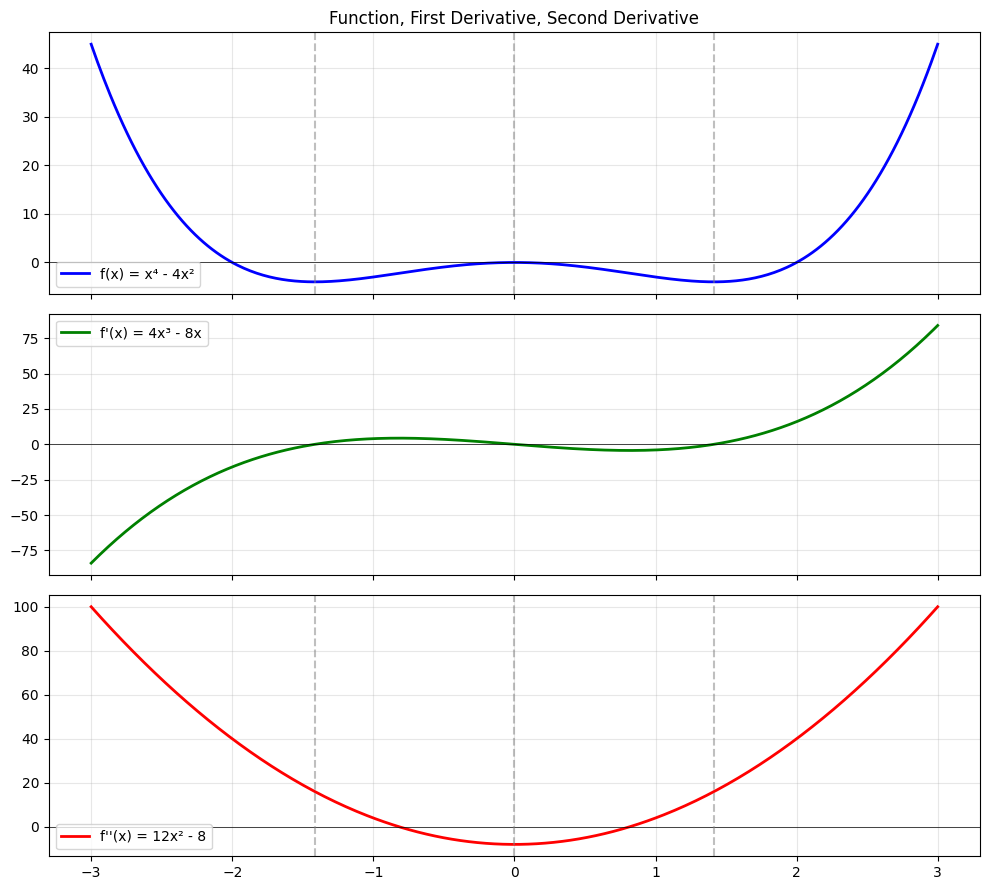

Critical points at x = [np.float64(-1.4142135623730951), 0, np.float64(1.4142135623730951)]
f'' at x=-sqrt(2): 16  (>0 => local min)
f'' at x=0:         -8  (<0 => local max)
f'' at x=+sqrt(2): 16  (>0 => local min)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 400)

# f(x) = x^4 - 4x^2
f = x**4 - 4*x**2
f1 = 4*x**3 - 8*x       # first derivative
f2 = 12*x**2 - 8         # second derivative

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, y, label, color in zip(axes,
        [f, f1, f2],
        ['f(x) = x⁴ - 4x²', "f'(x) = 4x³ - 8x", "f''(x) = 12x² - 8"],
        ['blue', 'green', 'red']):
    ax.plot(x, y, color=color, lw=2, label=label)
    ax.axhline(0, color='black', lw=0.5)
    ax.legend(); ax.grid(True, alpha=0.3)

axes[0].set_title('Function, First Derivative, Second Derivative')
# Mark critical points
for xc in [-np.sqrt(2), 0, np.sqrt(2)]:
    axes[0].axvline(xc, color='gray', ls='--', alpha=0.5)
    axes[2].axvline(xc, color='gray', ls='--', alpha=0.5)

plt.tight_layout(); plt.savefig('ch217_second_deriv.png', dpi=100); plt.show()
print("Critical points at x =", [-np.sqrt(2), 0, np.sqrt(2)])
print("f'' at x=-sqrt(2):", 12*2 - 8, " (>0 => local min)")
print("f'' at x=0:        ", 12*0 - 8, " (<0 => local max)")
print("f'' at x=+sqrt(2):", 12*2 - 8, " (>0 => local min)")


## The Second Derivative Test

At a critical point where f'(x) = 0:

| f''(x) | Conclusion |
|---|---|
| > 0 | Local minimum (bowl shape) |
| < 0 | Local maximum (hill shape) |
| = 0 | Inconclusive — need higher-order analysis |

For multivariable functions, the equivalent is the **Hessian matrix** *(forward reference: saddle points in ch214)*.

In [2]:
# Second derivative test automated
def f(x): return x**4 - 4*x**2
def f1(x): return 4*x**3 - 8*x
def f2(x): return 12*x**2 - 8

# Find critical points numerically via bisection segments
from scipy.optimize import brentq

# Brackets where f' changes sign
brackets = [(-2.5, -1.0), (-1.0, 0.5), (0.5, 2.5)]
print("Critical point analysis:")
print(f"{'x':>8}  {'f(x)':>10}  {"f''(x)":>10}  {'Type':>12}")
print("-" * 50)
for a, b in brackets:
    try:
        xc = brentq(f1, a, b)
        fxx = f2(xc)
        kind = 'local min' if fxx > 0 else ('local max' if fxx < 0 else 'inconclusive')
        print(f"{xc:>8.4f}  {f(xc):>10.4f}  {fxx:>10.4f}  {kind:>12}")
    except:
        pass


Critical point analysis:
       x        f(x)      f''(x)          Type
--------------------------------------------------
 -1.4142     -4.0000     16.0000     local min
 -0.0000     -0.0000     -8.0000     local max
  1.4142     -4.0000     16.0000     local min


## Numerical Second Derivative

The second derivative can be approximated using the finite difference:

```
f''(x) ≈ [f(x+h) - 2f(x) + f(x-h)] / h²
```

This is the **central difference** for the second derivative *(building on ch207 — Numerical Derivatives)*.

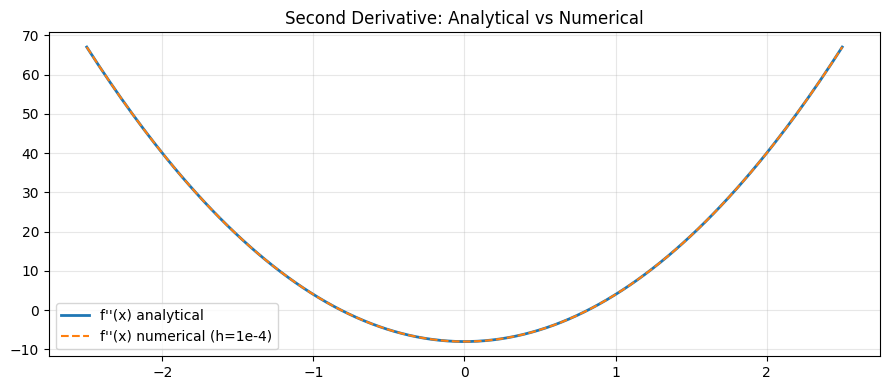

Max error: 9.37e-07


In [3]:
def second_deriv_numerical(f, x, h=1e-4):
    return (f(x + h) - 2*f(x) + f(x - h)) / h**2

x_vals = np.linspace(-2.5, 2.5, 200)
analytical = f2(x_vals)
numerical = second_deriv_numerical(f, x_vals)

plt.figure(figsize=(9, 4))
plt.plot(x_vals, analytical, lw=2, label="f''(x) analytical")
plt.plot(x_vals, numerical, '--', lw=1.5, label="f''(x) numerical (h=1e-4)")
plt.title("Second Derivative: Analytical vs Numerical")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch217_numerical.png', dpi=100); plt.show()
print(f"Max error: {np.max(np.abs(analytical - numerical)):.2e}")


## Summary

| Concept | Meaning |
|---|---|
| f''(x) > 0 | Concave up (function curves upward) |
| f''(x) < 0 | Concave down (function curves downward) |
| f''(x) = 0 | Inflection point (concavity changes) |
| Second derivative test | Classify critical points as min/max |

**Forward reference:** ch218 — Curvature generalises the second derivative idea to curves in the plane and connects it to geometry.